# Matplotlib Intro

In [1]:
# install datasets library (if not already installed)
!pip install datasets

#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import numpy as np

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


c:\Users\HP\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP\anaconda3\envs\python_course\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\datasets--lukebarousse--data_jobs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to act

In [30]:
pip list

Package                           Version
--------------------------------- --------------
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.3
aiosignal                         1.4.0
anyio                             4.11.0
argon2-cffi                       25.1.0
argon2-cffi-bindings              25.1.0
arrow                             1.3.0
asttokens                         3.0.0
async-lru                         2.0.5
attrs                             25.4.0
babel                             2.17.0
beautifulsoup4                    4.14.2
bleach                            6.2.0
brotlicffi                        1.2.0.0
certifi                           2025.10.5
cffi                              2.0.0
charset-normalizer                3.4.3
click                             8.2.1
colorama                          0.4.6
comm                              0.2.3
contourpy                         1.3.3
cycler          

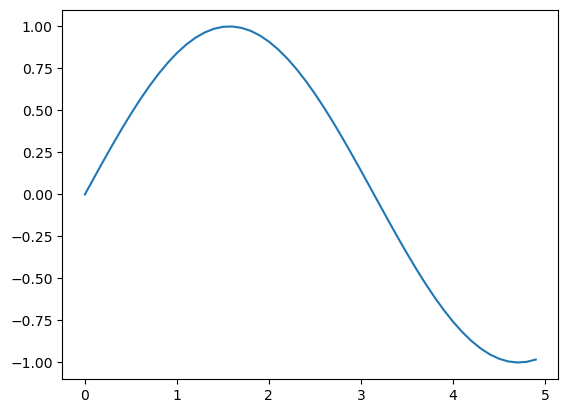

In [3]:
x= np.arange(0,5,0.1)
y= np.sin(x)
plt.plot(x,y)

# Line Chart


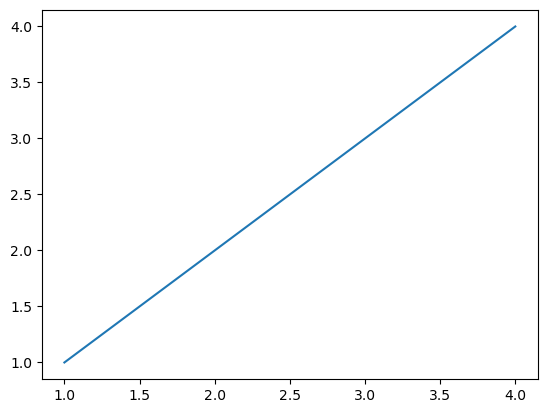

In [4]:
x = [1,2,3,4]
y = [1,2,3,4]

plt.plot(x,y)
plt.show()

# Plotting Job Postings Dates

In [5]:
df.job_posted_date.head()

0   2023-06-16 13:44:15
1   2023-01-14 13:18:07
2   2023-10-10 13:14:55
3   2023-07-04 13:01:41
4   2023-08-07 14:29:36
Name: job_posted_date, dtype: datetime64[us]

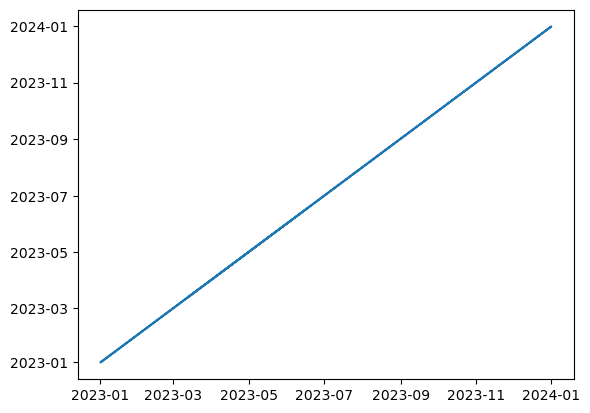

In [6]:
plt.plot(df.job_posted_date, df.job_posted_date)


In [7]:
date_counts = df.job_posted_date.value_counts()
date_counts  = date_counts.sort_index()

In [8]:
type(date_counts)

pandas.Series

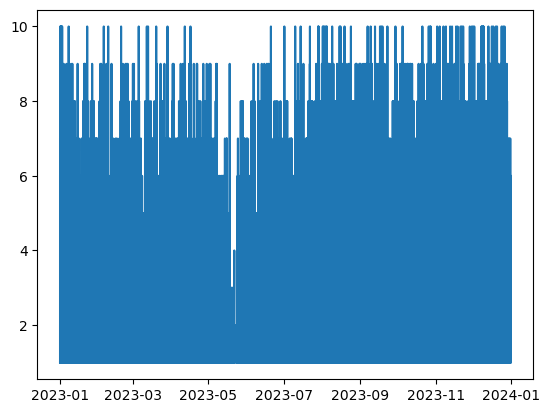

In [9]:
plt.plot(date_counts.index, date_counts)

In [10]:
date_counts

job_posted_date
2023-01-01 00:00:04    1
2023-01-01 00:00:07    1
2023-01-01 00:00:22    1
2023-01-01 00:00:24    1
2023-01-01 00:00:27    1
                      ..
2023-12-31 23:40:18    2
2023-12-31 23:40:22    2
2023-12-31 23:40:31    2
2023-12-31 23:40:32    1
2023-12-31 23:59:58    2
Name: count, Length: 607192, dtype: int64

In [11]:
df['job_posted_month'] = df['job_posted_date'].dt.month

In [12]:
monthly_counts = df.job_posted_month.value_counts()
monthly_counts = monthly_counts.sort_index()
monthly_counts

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

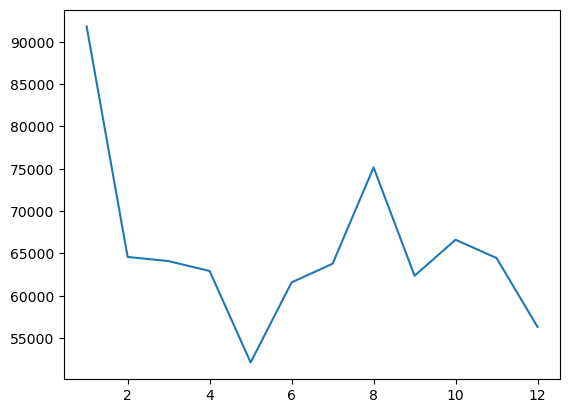

In [13]:
plt.plot(monthly_counts.index, monthly_counts)

# Series Vs DataFrame

In [14]:
series = pd.Series([10,20,30,40,50],index = ['a','b','c','d','e'])

In [15]:
series.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='str')

In [16]:
series.values

array([10, 20, 30, 40, 50])

In [17]:
df.job_title_short.value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [18]:
job_counts = df.job_title_short.value_counts()
job_counts = job_counts.sort_values(ascending = False)

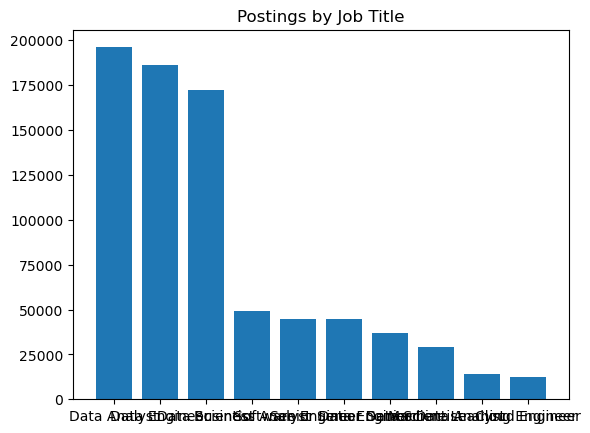

In [19]:
plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.show()

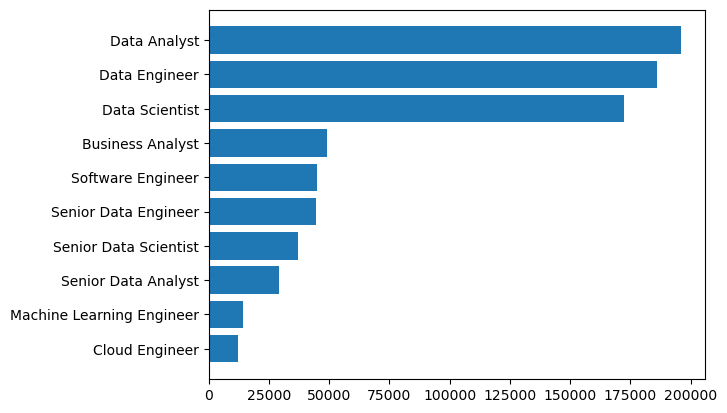

In [20]:
job_counts = job_counts.sort_values(ascending= True)
plt.barh(job_counts.index, job_counts)
plt.show()

# Labeling

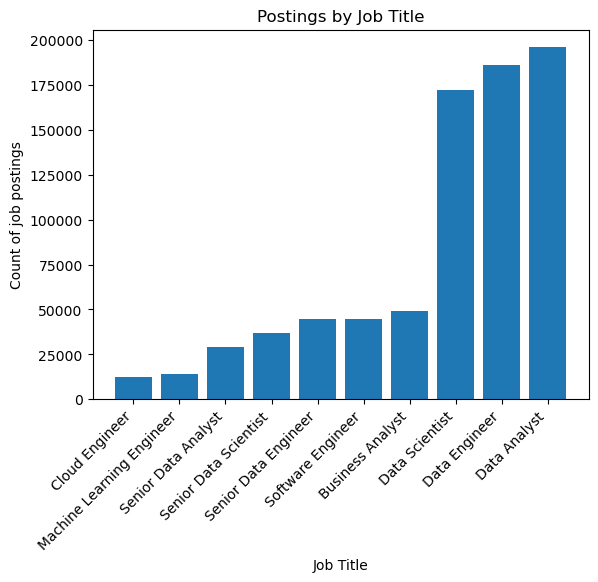

In [21]:
plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count of job postings')
plt.xticks(rotation = 45,ha='right')
plt.show()


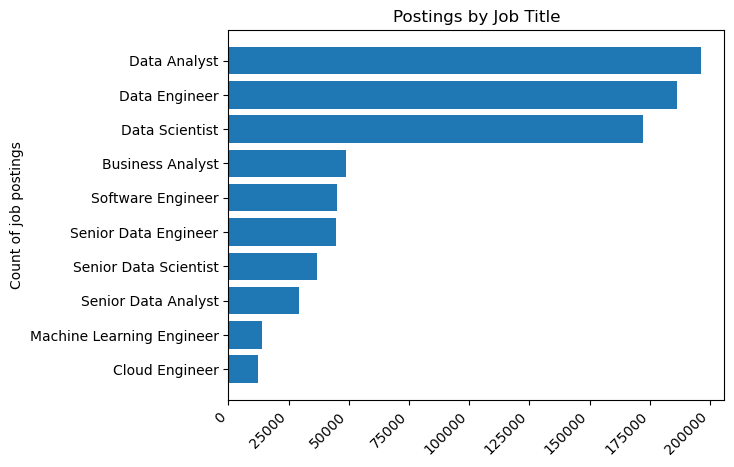

In [22]:
plt.barh(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.ylabel('Count of job postings')
plt.xticks(rotation = 45, ha='right')
plt.show()

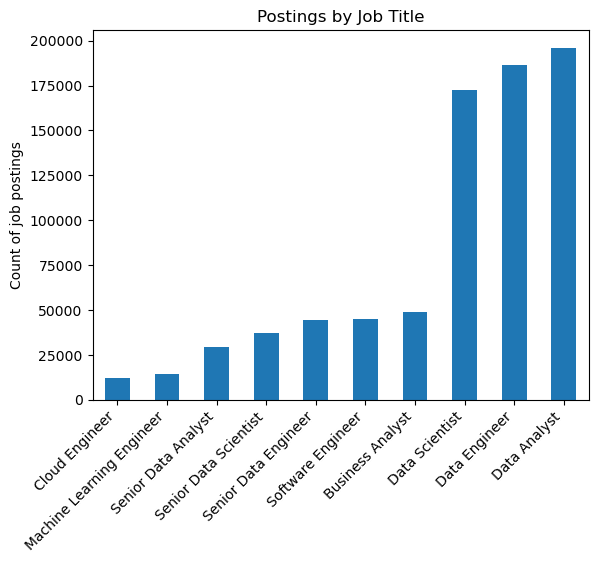

In [23]:
job_counts.plot(kind = 'bar')
plt.title('Postings by Job Title')
plt.xlabel('')
plt.ylabel('Count of job postings')
plt.xticks(rotation = 45, ha='right')
plt.show()

In [24]:
type(df)

pandas.DataFrame

<Axes: xlabel='job_posted_date'>

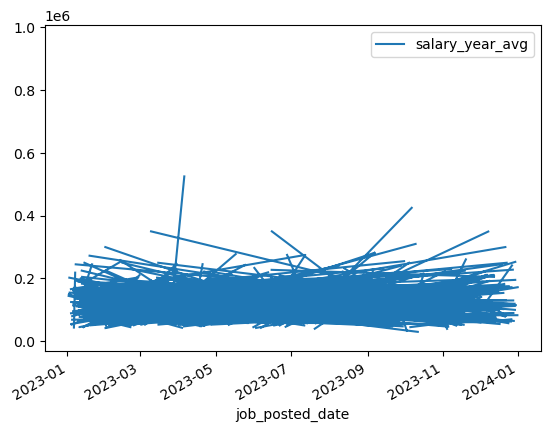

In [25]:
df.plot(x='job_posted_date', y='salary_year_avg', kind = 'line')

# Median Salary vs Data Science Jobs

In [26]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [27]:
df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Software Engineer             99150.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Data Engineer                125000.0
Data Scientist               127500.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Name: salary_year_avg, dtype: float64

In [28]:
jobs_salary = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values()

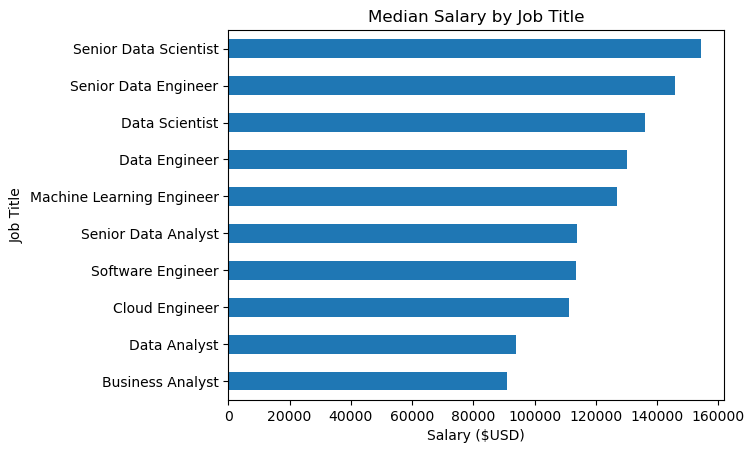

In [29]:
jobs_salary.plot(kind = 'barh')
plt.xlabel('Salary ($USD)')
plt.ylabel('Job Title')
plt.title('Median Salary by Job Title')
plt.show()

# From here the works are done in Visual studio Code